# 1. Perkenalan Dataset

**Nama:** Ahmad Fauzul Adhim  
**Dataset:** Heart Failure Prediction Dataset  
**URL Sumber:** [Kaggle Heart Failure Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)


**Deskripsi Dataset:**

Dataset Heart Failure Prediction merupakan kumpulan data klinis pasien yang digabungkan dari 5 dataset jantung independen (Cleveland, Hungarian, Switzerland, Long Beach VA, dan Stalog). Dataset ini berisi **918 instance** dengan **11 fitur klinis** dan 1 label kelas biner.

**Fitur-fitur dataset:**
| Fitur | Deskripsi | Tipe |
|-------|-----------|------|
| `Age` | Usia pasien (tahun) | Numerik |
| `Sex` | Jenis kelamin (M=Pria, F=Wanita) | Kategorikal |
| `ChestPainType` | Tipe nyeri dada (TA, ATA, NAP, ASY) | Kategorikal |
| `RestingBP` | Tekanan darah saat istirahat (mm Hg) | Numerik |
| `Cholesterol` | Kolesterol serum (mg/dl) | Numerik |
| `FastingBS` | Gula darah puasa > 120 mg/dl (1=Ya, 0=Tidak) | Kategorikal |
| `RestingECG` | Hasil EKG saat istirahat (Normal, ST, LVH) | Kategorikal |
| `MaxHR` | Detak jantung maksimum yang dicapai | Numerik |
| `ExerciseAngina` | Angina akibat olahraga (Y=Ya, N=Tidak) | Kategorikal |
| `Oldpeak` | Depresi ST akibat olahraga relatif terhadap istirahat | Numerik |
| `ST_Slope` | Kemiringan segmen ST puncak saat olahraga (Up, Flat, Down) | Kategorikal |

**Target:** Kolom `HeartDisease` — nilai 0 menunjukkan tidak ada penyakit jantung, nilai 1 menunjukkan adanya penyakit jantung.

**Tantangan utama:**
- Fitur kategorikal bertipe string memerlukan encoding sebelum digunakan pada model.
- Terdapat potensi class imbalance antara pasien sehat dan sakit.
- Campuran fitur numerik dan kategorikal memerlukan preprocessing yang berbeda.


# 2. Import Library

In [1]:
# Install semua dependensi yang dibutuhkan
%pip install -q "numpy>=1.24" "pandas>=2.0" "matplotlib>=3.7" "seaborn>=0.12" \
    "scikit-learn>=1.3" "imbalanced-learn>=0.11" "mlflow>=2.10" "joblib>=1.3"


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\muthi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import mlflow
import mlflow.sklearn
import shutil

from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE
from matplotlib.patches import Patch

try:
    from IPython.display import display
except ImportError:
    display = print  # fallback jika bukan di Jupyter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded successfully.')


Libraries loaded successfully.


# 3. Memuat Dataset

In [3]:
DATA_PATH = 'heart.csv'

# Load dataset
df = pd.read_csv(DATA_PATH)

# Tampilkan informasi dasar
print("=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
print(f"\nShape: {df.shape}")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

print("\n--- Head Dataset ---")
df.head(10)

INFORMASI DATASET

Shape: (918, 12)
Jumlah baris: 918
Jumlah kolom: 12

--- Head Dataset ---


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [4]:
# Info tipe data
print("\n--- Info Dataset ---")
df.info()


--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
# Statistik deskriptif
print("\n--- Statistik Deskriptif ---")
df.describe()


--- Statistik Deskriptif ---


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
# Statistik deskriptif untuk kolom kategorikal
print("\n--- Statistik Kategorikal ---")
df.describe(include='object')


--- Statistik Kategorikal ---


,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


In [7]:
# Distribusi target tanpa menambahkan duplikat label ke dataframe
target_series = df['HeartDisease']

print('=== Distribusi Target Biner ===')
target_counts = target_series.value_counts().sort_index()
target_labels = {0: 'Sehat (0)', 1: 'Penyakit Jantung (1)'}
for k, v in target_counts.items():
    print(f'  {target_labels[k]}: {v} ({v/len(df)*100:.1f}%)')


=== Distribusi Target Biner ===
  Sehat (0): 410 (44.7%)
  Penyakit Jantung (1): 508 (55.3%)


# 4. Exploratory Data Analysis (EDA)

In [8]:
# 2.1 Cek Missing Values
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

MISSING VALUES
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Total missing values: 0


In [9]:
# 2.2 Cek Duplicate
print("\n" + "=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
print(f"Jumlah duplikat: {df.duplicated().sum()}")


DUPLICATE ROWS
Jumlah duplikat: 0



DISTRIBUSI TARGET (HeartDisease)
HeartDisease
1    508
0    410
Name: count, dtype: int64

Persentase:
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


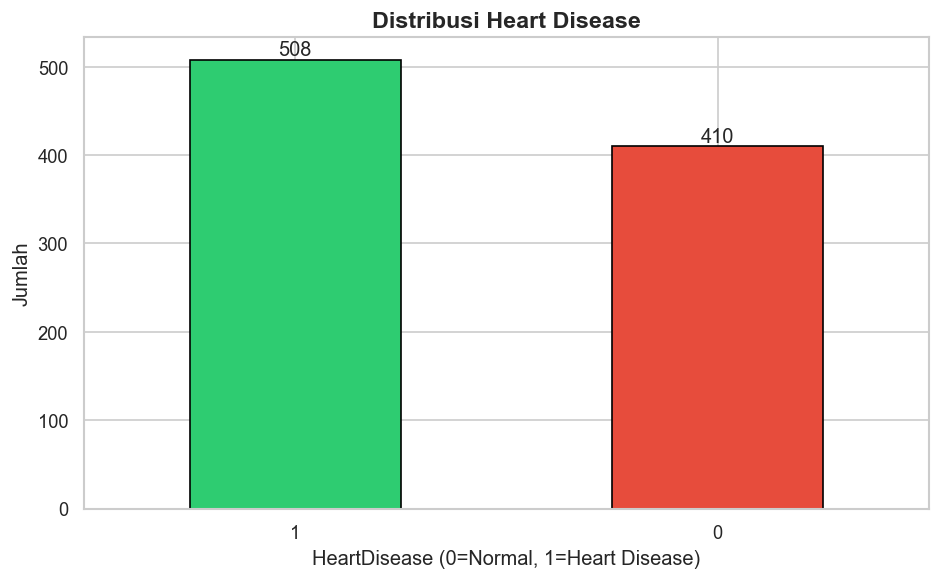

In [10]:
# 2.3 Distribusi Target Variable
print("\n" + "=" * 50)
print("DISTRIBUSI TARGET (HeartDisease)")
print("=" * 50)
print(df['HeartDisease'].value_counts())
print(f"\nPersentase:")
print(df['HeartDisease'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
ax = df['HeartDisease'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Distribusi Heart Disease', fontsize=14, fontweight='bold')
plt.xlabel('HeartDisease (0=Normal, 1=Heart Disease)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

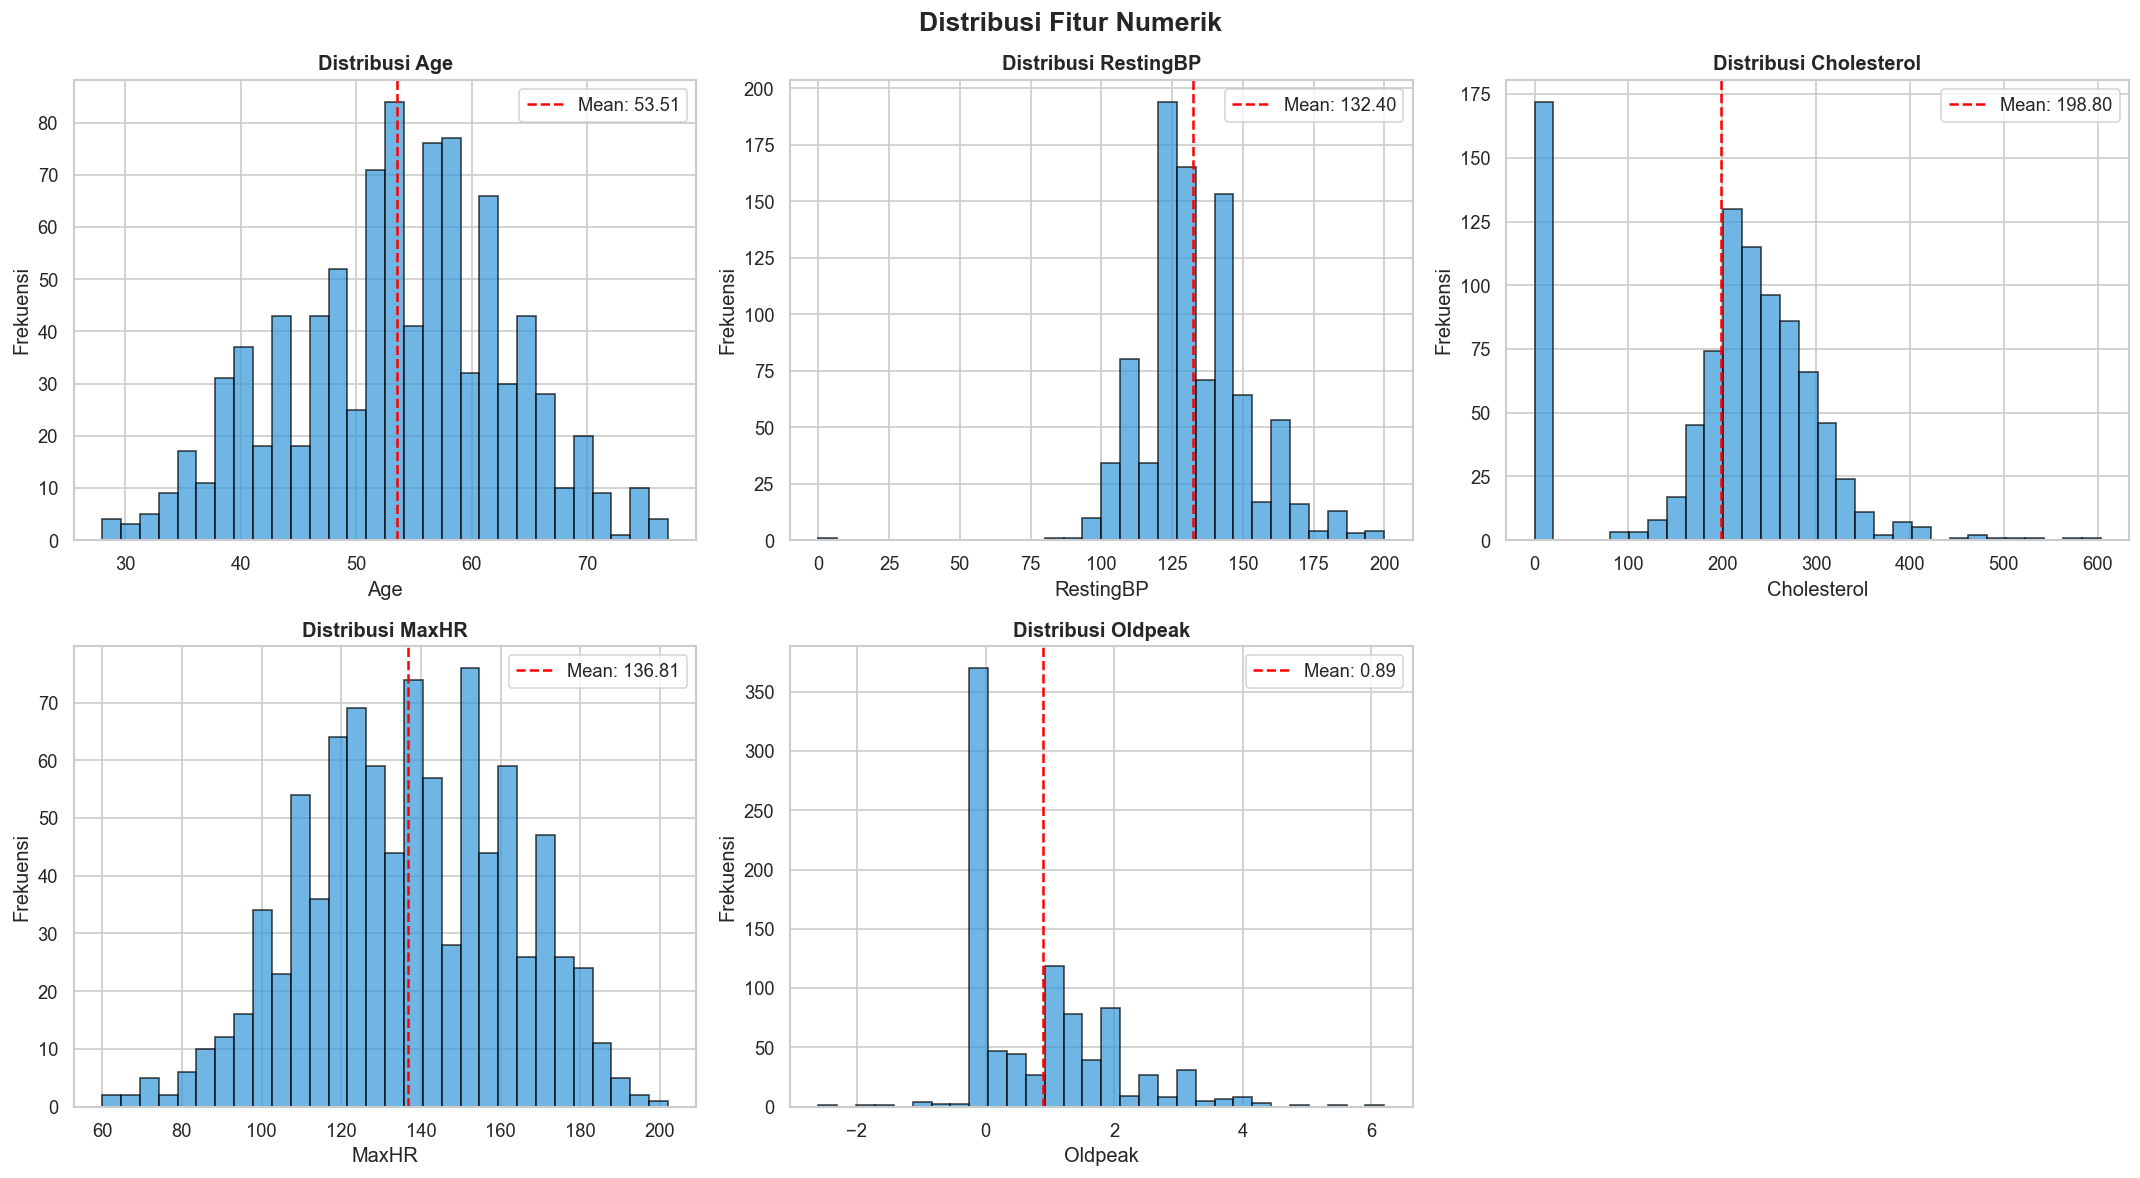

In [11]:
# 2.4 Distribusi Fitur Numerik
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].legend()

axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

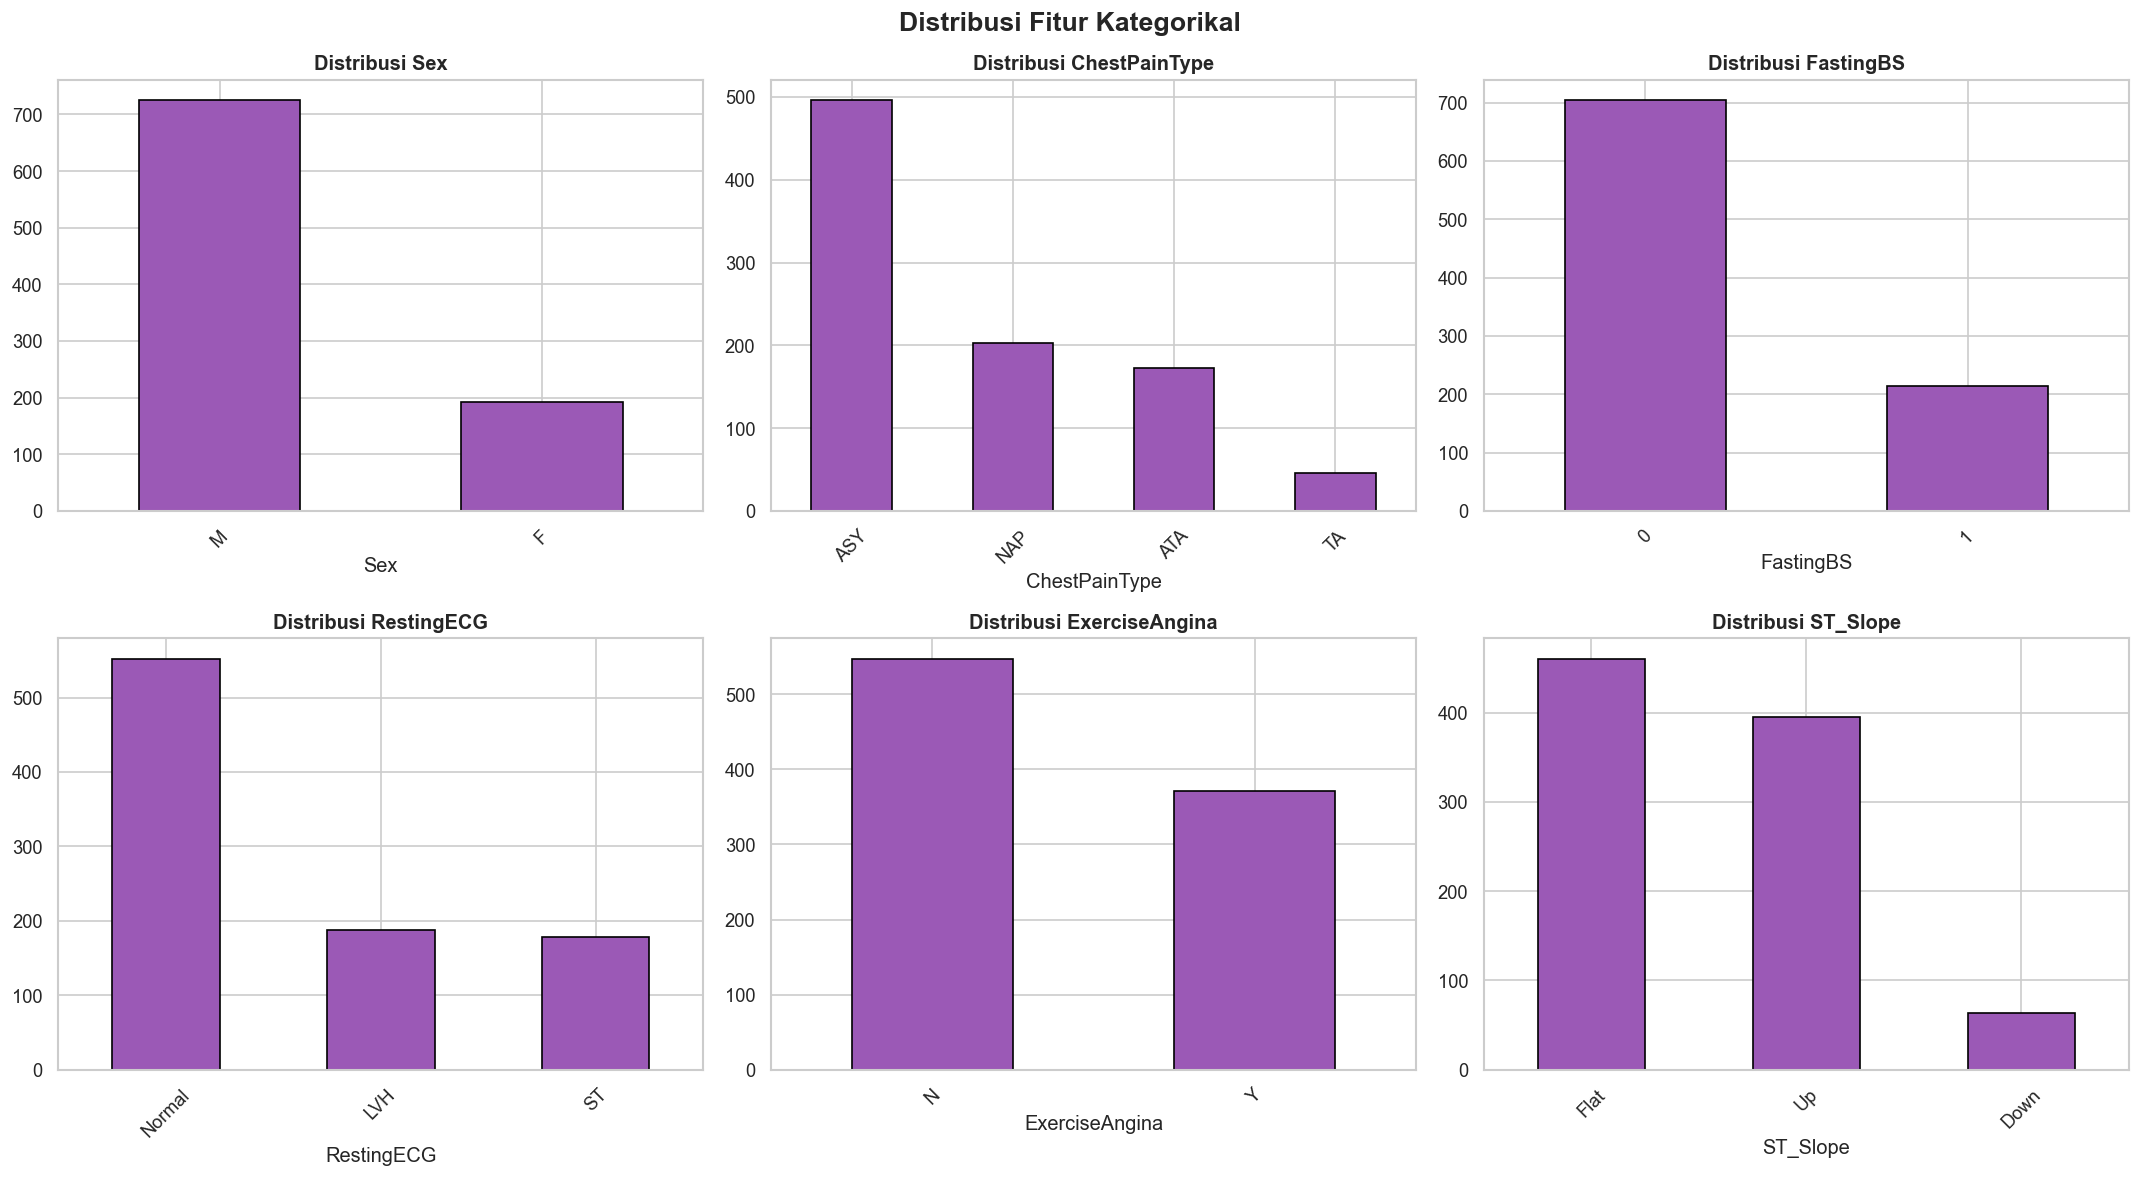

In [12]:
# 2.5 Distribusi Fitur Kategorikal
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='#9b59b6', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

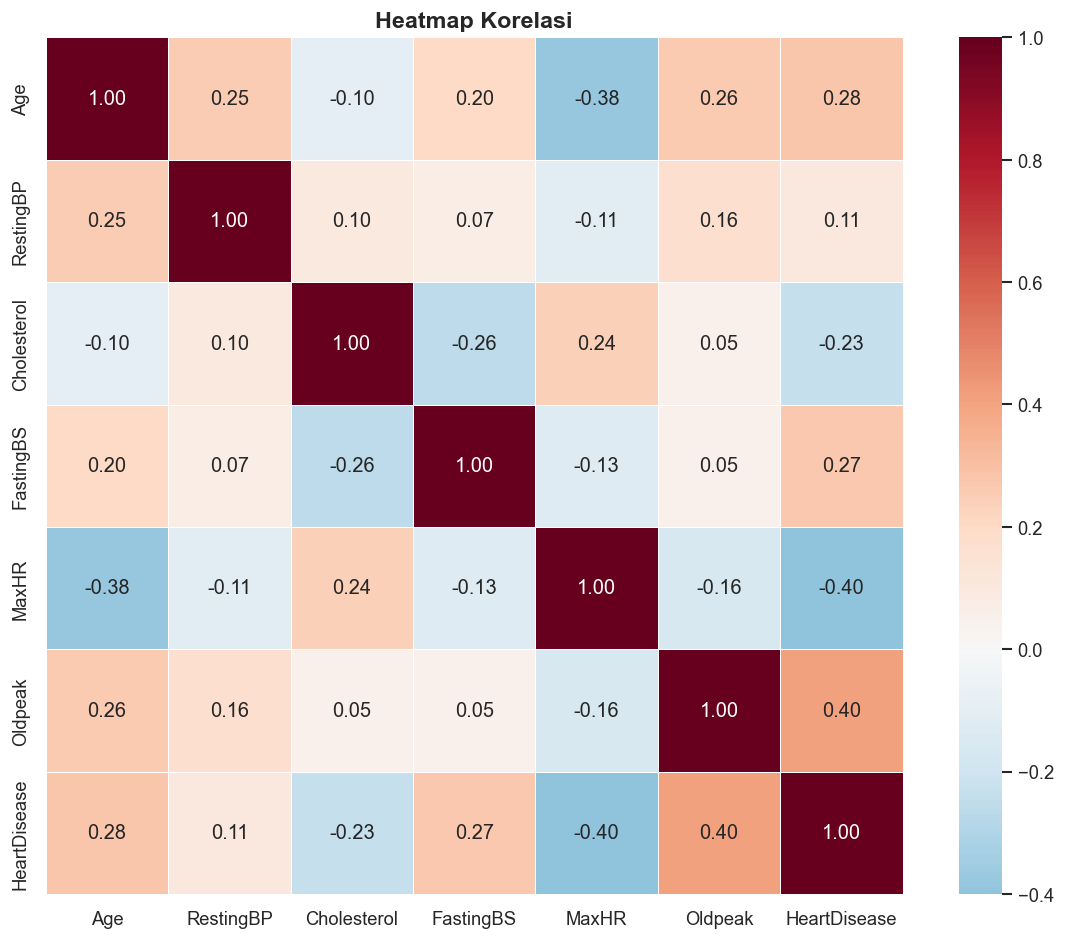

In [13]:
# 2.6 Korelasi antar fitur numerik
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Heatmap Korelasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

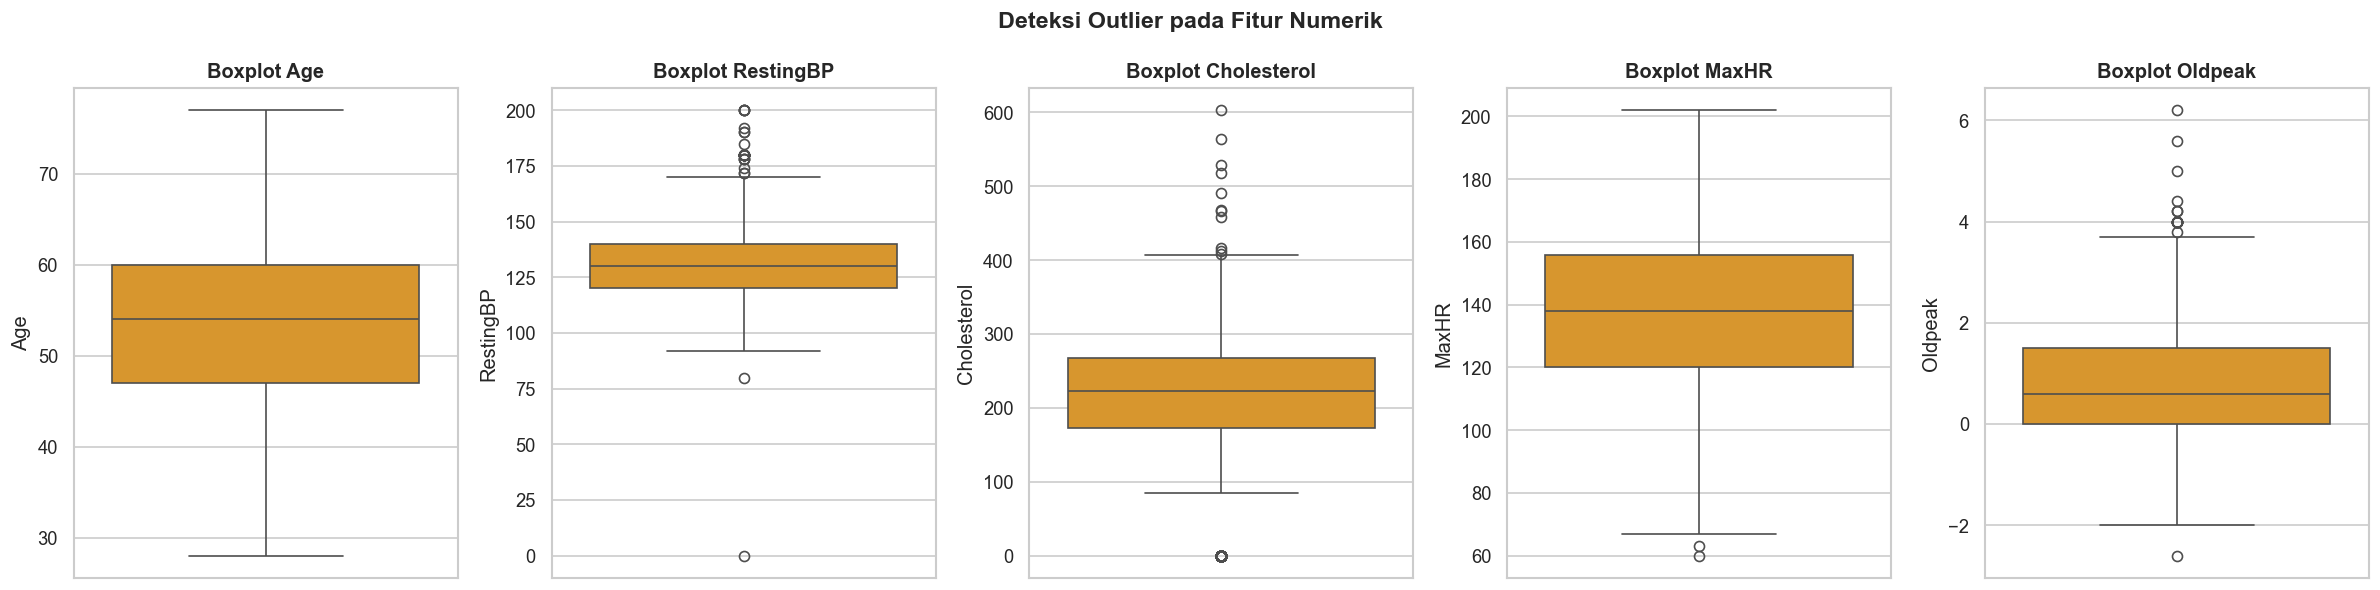

In [14]:
# 2.7 Boxplot - Deteksi Outlier
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='#f39c12')
    axes[i].set_title(f'Boxplot {col}', fontweight='bold')
plt.suptitle('Deteksi Outlier pada Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# 2.8 Analisis Cholesterol = 0 (anomali)
print(f"Jumlah data dengan Cholesterol = 0: {(df['Cholesterol'] == 0).sum()}")
print(f"Persentase: {(df['Cholesterol'] == 0).sum() / len(df) * 100:.2f}%")

Jumlah data dengan Cholesterol = 0: 172
Persentase: 18.74%


In [16]:
# 2.9 Analisis RestingBP = 0 (anomali)
print(f"Jumlah data dengan RestingBP = 0: {(df['RestingBP'] == 0).sum()}")
print(f"Persentase: {(df['RestingBP'] == 0).sum() / len(df) * 100:.2f}%")

Jumlah data dengan RestingBP = 0: 1
Persentase: 0.11%


# 5. Data Preprocessing

In [17]:
df_clean = df.copy()

# 3.1 Handle anomali: Cholesterol = 0 → ganti dengan median
cholesterol_median = df_clean[df_clean['Cholesterol'] > 0]['Cholesterol'].median()
df_clean.loc[df_clean['Cholesterol'] == 0, 'Cholesterol'] = cholesterol_median
print(f"Cholesterol 0 diganti dengan median: {cholesterol_median}")

# 3.2 Handle anomali: RestingBP = 0 → ganti dengan median
if (df_clean['RestingBP'] == 0).sum() > 0:
    bp_median = df_clean[df_clean['RestingBP'] > 0]['RestingBP'].median()
    df_clean.loc[df_clean['RestingBP'] == 0, 'RestingBP'] = bp_median
    print(f"RestingBP 0 diganti dengan median: {bp_median}")
else:
    print("Tidak ada anomali RestingBP = 0")

print(f"\nShape setelah handle anomali: {df_clean.shape}")

Cholesterol 0 diganti dengan median: 237.0
RestingBP 0 diganti dengan median: 130.0

Shape setelah handle anomali: (918, 12)


In [18]:
# 3.3 Handle Outlier menggunakan IQR Method (opsional, hati-hati tidak menghilangkan terlalu banyak data)
def handle_outliers_iqr(df, column, factor=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    # Cap outlier (bukan hapus, agar data tidak hilang)
    df[column] = df[column].clip(lower=lower, upper=upper)
    return df

# Terapkan capping pada kolom yang memiliki outlier signifikan
for col in ['RestingBP', 'Cholesterol', 'Oldpeak']:
    df_clean = handle_outliers_iqr(df_clean, col)
    
print("Outlier berhasil di-cap menggunakan metode IQR")

Outlier berhasil di-cap menggunakan metode IQR


In [19]:
# 3.4 Encoding Fitur Kategorikal
# Label Encoding untuk fitur binary
le_sex = LabelEncoder()
df_clean['Sex'] = le_sex.fit_transform(df_clean['Sex'])  # F=0, M=1

le_angina = LabelEncoder()
df_clean['ExerciseAngina'] = le_angina.fit_transform(df_clean['ExerciseAngina'])  # N=0, Y=1

# One-Hot Encoding untuk fitur multi-kategori
df_clean = pd.get_dummies(df_clean, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], 
                          drop_first=True, dtype=int)

print("Encoding selesai!")
print(f"Shape setelah encoding: {df_clean.shape}")
print(f"\nKolom: {list(df_clean.columns)}")

Encoding selesai!
Shape setelah encoding: (918, 16)

Kolom: ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


In [20]:
# 3.5 Feature Scaling
# ⚠️  PENTING: Scaling TIDAK dilakukan di sini untuk menghindari data leakage.
#     StandardScaler akan di-fit HANYA pada X_train setelah split (lihat Cell 3.6).
#     Melakukan fit_transform pada seluruh df_clean sebelum split menyebabkan
#     statistik (mean/std) dari data test 'bocor' ke dalam proses training.

numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()  # Objek scaler disiapkan, fitting dilakukan di Cell 3.6

print('✅ StandardScaler disiapkan (fitting dilakukan setelah split).')
print(f'   Fitur numerik: {numerical_features}')
df_clean.head()


✅ StandardScaler disiapkan (fitting dilakukan setelah split).
   Fitur numerik: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289.0,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,0,160,180.0,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,1,130,283.0,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,0,138,214.0,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,1,150,195.0,0,122,0,0.0,0,0,1,0,1,0,0,1


In [21]:
# 3.6 Split Data: Train & Test
# Pastikan label tidak ikut masuk sebagai fitur agar tidak terjadi target leakage.
target_col   = 'HeartDisease'
leakage_cols = [target_col, 'target']
feature_cols = [col for col in df_clean.columns if col not in leakage_cols]

X = df_clean[feature_cols].copy()
y = df_clean[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ FIX: Scaling dilakukan SETELAH split
#    - fit_transform pada X_train (scaler belajar dari training data saja)
#    - transform (tanpa fit) pada X_test / X_test_proc
X_test_proc = X_test.copy()
X_train[numerical_features]     = scaler.fit_transform(X_train[numerical_features])
X_test_proc[numerical_features] = scaler.transform(X_test_proc[numerical_features])

# Alias yang digunakan pada section Modeling.
feature_names_out = X_train.columns.to_numpy()
numeric_features  = [col for col in numerical_features if col in X_train.columns]

class_counts    = y_train.value_counts().sort_index()
imbalance_ratio = class_counts.min() / class_counts.max()
smote_applied   = imbalance_ratio < 0.8

if smote_applied:
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
else:
    X_train_res, y_train_res = X_train.copy(), y_train.copy()

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train distribution:\n{y_train.value_counts()}')
print(f'y_test  distribution:\n{y_test.value_counts()}')
print(f'Imbalance ratio train : {imbalance_ratio:.3f}')
print(f'SMOTE applied         : {smote_applied}')
print(f'X_train_res shape     : {X_train_res.shape}')
print(f'y_train_res distribution:\n{pd.Series(y_train_res).value_counts()}')


X_train shape : (734, 15)
X_test  shape : (184, 15)
y_train distribution:
HeartDisease
1    406
0    328
Name: count, dtype: int64
y_test  distribution:
HeartDisease
1    102
0     82
Name: count, dtype: int64
Imbalance ratio train : 0.808
SMOTE applied         : False
X_train_res shape     : (734, 15)
y_train_res distribution:
HeartDisease
1    406
0    328
Name: count, dtype: int64


In [22]:
# 3.7 Simpan Dataset yang Sudah Dipreprocessing
# Simpan dataset tanpa kolom target duplikat agar script modeling tidak mengalami leakage.
df_preprocessed = df_clean.drop(columns=['target'], errors='ignore')
df_preprocessed.to_csv('heart_preprocessing.csv', index=False)
print("Dataset preprocessing berhasil disimpan ke 'heart_preprocessing.csv'")


Dataset preprocessing berhasil disimpan ke 'heart_preprocessing.csv'


# 6. Modeling

## 6.1 Baseline Random Forest

In [23]:
print('=== Training Baseline Random Forest ===')
t_start = time.time()

baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
baseline_rf.fit(X_train_res, y_train_res)

t_elapsed = time.time() - t_start
y_pred_base = baseline_rf.predict(X_test_proc)

print(f'Training time   : {t_elapsed:.2f} detik')
print(f'Accuracy (Test) : {accuracy_score(y_test, y_pred_base):.4f}')
print(f'F1-Score (Test) : {f1_score(y_test, y_pred_base):.4f}')
print(f'\n=== Classification Report (Baseline) ===')
print(classification_report(y_test, y_pred_base,
                             target_names=['Sehat', 'Penyakit Jantung'], digits=4))

=== Training Baseline Random Forest ===
Training time   : 0.59 detik
Accuracy (Test) : 0.8587
F1-Score (Test) : 0.8713

=== Classification Report (Baseline) ===
                  precision    recall  f1-score   support

           Sehat     0.8333    0.8537    0.8434        82
Penyakit Jantung     0.8800    0.8627    0.8713       102

        accuracy                         0.8587       184
       macro avg     0.8567    0.8582    0.8573       184
    weighted avg     0.8592    0.8587    0.8588       184



## 6.2 Hyperparameter Tuning dengan GridSearchCV

In [24]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'class_weight'     : [None, 'balanced']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',           # Prioritas F1-score untuk data medis
    n_jobs=-1,
    verbose=1,
    refit=True
)

print('=== Memulai GridSearchCV... ===')
t_start = time.time()
grid_search.fit(X_train_res, y_train_res)
t_elapsed = time.time() - t_start

best_model  = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f'\nWaktu Grid Search : {t_elapsed:.1f} detik')
print(f'Best CV F1-Score  : {grid_search.best_score_:.4f}')
print(f'Best Parameters   :')
for k, v in best_params.items():
    print(f'  {k}: {v}')

=== Memulai GridSearchCV... ===
Fitting 5 folds for each of 162 candidates, totalling 810 fits

Waktu Grid Search : 886.2 detik
Best CV F1-Score  : 0.8831
Best Parameters   :
  class_weight: None
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 100


## 6.3 Evaluasi Model Terbaik

=== Metrik Evaluasi – Best Model (Test Set) ===
  Accuracy  : 0.8587
  Precision : 0.8800
  Recall    : 0.8627
  F1-Score  : 0.8713
  ROC-AUC   : 0.9272

=== Classification Report ===
                  precision    recall  f1-score   support

           Sehat     0.8333    0.8537    0.8434        82
Penyakit Jantung     0.8800    0.8627    0.8713       102

        accuracy                         0.8587       184
       macro avg     0.8567    0.8582    0.8573       184
    weighted avg     0.8592    0.8587    0.8588       184



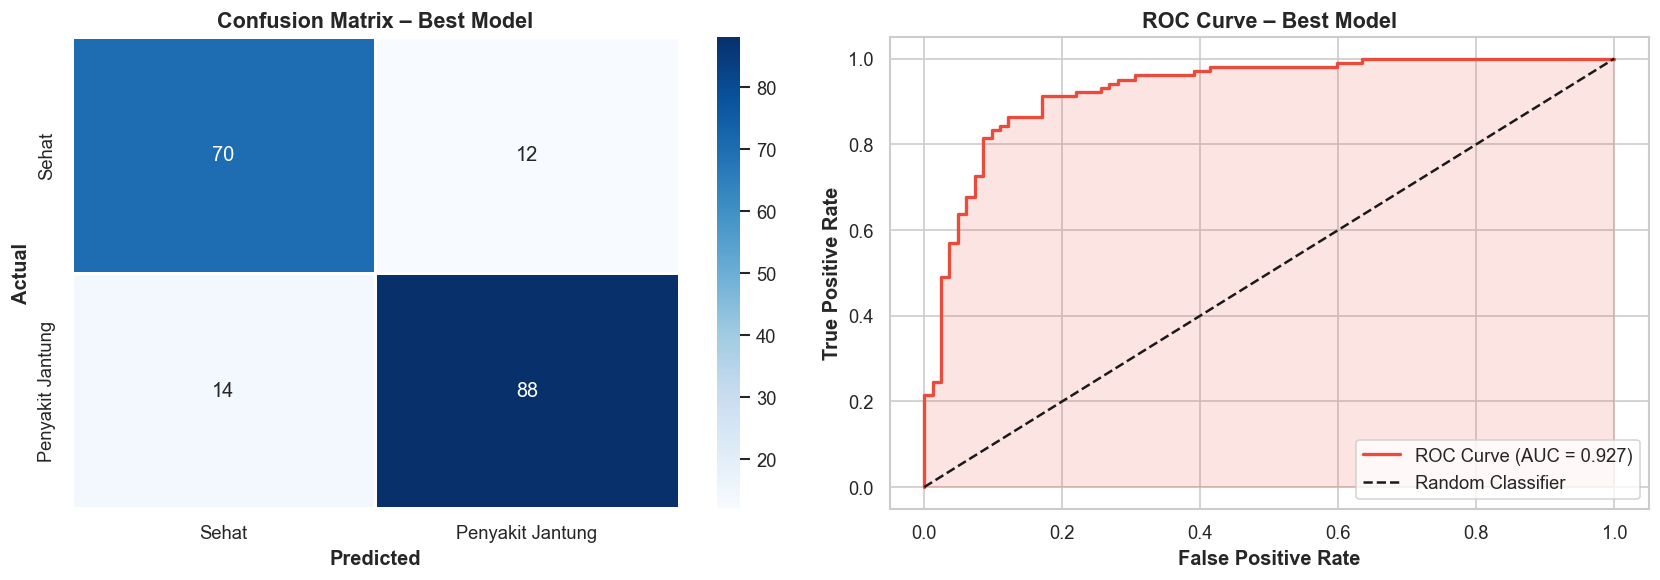

In [25]:
y_pred_best = best_model.predict(X_test_proc)
y_prob_best = best_model.predict_proba(X_test_proc)[:, 1]

acc_best   = accuracy_score(y_test, y_pred_best)
f1_best    = f1_score(y_test, y_pred_best)
prec_best  = precision_score(y_test, y_pred_best)
rec_best   = recall_score(y_test, y_pred_best)
roc_best   = roc_auc_score(y_test, y_prob_best)

print('=== Metrik Evaluasi – Best Model (Test Set) ===')
print(f'  Accuracy  : {acc_best:.4f}')
print(f'  Precision : {prec_best:.4f}')
print(f'  Recall    : {rec_best:.4f}')
print(f'  F1-Score  : {f1_best:.4f}')
print(f'  ROC-AUC   : {roc_best:.4f}')

print(f'\n=== Classification Report ===')
print(classification_report(y_test, y_pred_best,
                             target_names=['Sehat', 'Penyakit Jantung'], digits=4))

# Confusion matrix & ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.8,
            xticklabels=['Sehat', 'Penyakit Jantung'],
            yticklabels=['Sehat', 'Penyakit Jantung'], ax=axes[0])
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title('Confusion Matrix – Best Model', fontsize=13, fontweight='bold')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {roc_best:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].set_title('ROC Curve – Best Model', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 6.4 Feature Importance

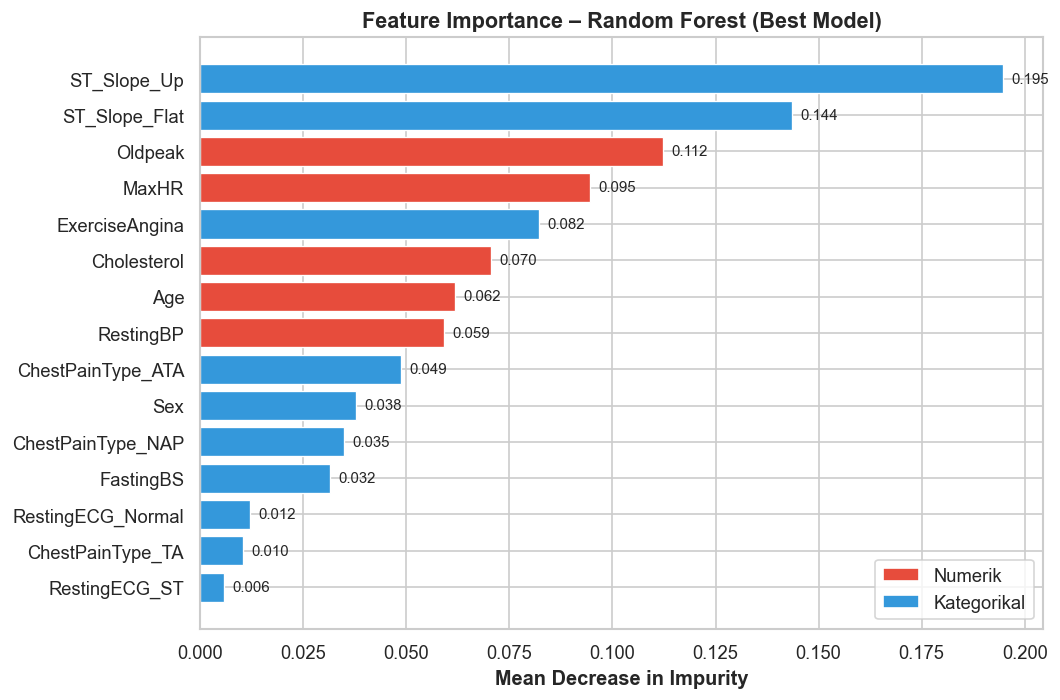


=== Top 5 Fitur Paling Penting ===
       Feature  Importance
   ST_Slope_Up    0.194655
 ST_Slope_Flat    0.143506
       Oldpeak    0.112245
         MaxHR    0.094623
ExerciseAngina    0.082231


In [26]:
importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature'   : feature_names_out,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if f in numeric_features else '#3498db' for f in feat_imp_df['Feature']]
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
               color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, feat_imp_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

# Patch sudah diimport di bagian atas notebook
legend_elements = [
    Patch(facecolor='#e74c3c', label='Numerik'),
    Patch(facecolor='#3498db', label='Kategorikal')
]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_xlabel('Mean Decrease in Impurity', fontweight='bold')
ax.set_title('Feature Importance – Random Forest (Best Model)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Top 5 Fitur Paling Penting ===')
print(feat_imp_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))


## 6.5 MLflow Experiment Tracking

In [27]:
# Konfigurasi MLflow tracking directory
mlflow_dir = Path('./mlflow_artifacts').resolve()
mlflow_dir.mkdir(exist_ok=True, parents=True)

# ✅ FIX: Gunakan .as_uri() agar format file URI selalu benar
#    di Windows maupun Unix/Linux.
#    Bug lama: f'file:///{mlflow_dir}' → menghasilkan 'file:////path' di Unix
#    karena mlflow_dir sudah dimulai dengan '/' (absolute path).
mlflow.set_tracking_uri(mlflow_dir.as_uri())

print(f'✅ MLflow tracking URI  : {mlflow.get_tracking_uri()}')
print(f'✅ Artifacts direktori  : {mlflow_dir}')


✅ MLflow tracking URI  : file:///D:/DICODING%20x%20PIJAK/SUBMISSION/MEMBANGUN%20SISTEM%20MACHINE%20LEARNING/Eksperimen_SML_Ahmad_Fauzul_Adhim/preprocessing/mlflow_artifacts
✅ Artifacts direktori  : D:\DICODING x PIJAK\SUBMISSION\MEMBANGUN SISTEM MACHINE LEARNING\Eksperimen_SML_Ahmad_Fauzul_Adhim\preprocessing\mlflow_artifacts


In [28]:
EXPERIMENT_NAME = 'HeartFailurePrediction_RandomForest'
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name='RF_GridSearchCV_Best') as run:

    # --- Log Parameters ---
    for k, v in best_params.items():
        mlflow.log_param(f'best_{k}', v)
    mlflow.log_param('smote_applied', smote_applied)
    mlflow.log_param('train_size', X_train_res.shape[0])
    mlflow.log_param('test_size', X_test_proc.shape[0])
    mlflow.log_param('n_features', X_train_res.shape[1])

    # --- Log Metrics ---
    mlflow.log_metric('accuracy',  acc_best)
    mlflow.log_metric('precision', prec_best)
    mlflow.log_metric('recall',    rec_best)
    mlflow.log_metric('f1_score',  f1_best)
    mlflow.log_metric('roc_auc',   roc_best)

    # --- Log Model ---
    mlflow.sklearn.log_model(sk_model=best_model, artifact_path='best_rf_model')

    # --- Log Confusion Matrix sebagai Artefak ---
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sehat', 'Penyakit Jantung'],
                yticklabels=['Sehat', 'Penyakit Jantung'], ax=ax_cm)
    ax_cm.set_title('Confusion Matrix')
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')
    plt.tight_layout()
    fig_cm.savefig('confusion_matrix.png', dpi=100)
    mlflow.log_artifact('confusion_matrix.png')
    plt.close(fig_cm)

    # --- Simpan model lokal sebagai backup ---
    local_export = './best_rf_heartfailure_model'
    if os.path.exists(local_export):
        shutil.rmtree(local_export)
    mlflow.sklearn.save_model(sk_model=best_model, path=local_export)

    run_id = run.info.run_id

print(f'\n MLflow run selesai!')
print(f'   Experiment : {EXPERIMENT_NAME}')
print(f'   Run ID     : {run_id}')
print(f'   Accuracy   : {acc_best:.4f}')
print(f'   F1-Score   : {f1_best:.4f}')
print(f'   ROC-AUC    : {roc_best:.4f}')
print(f'\n Model lokal tersimpan di: {local_export}/')
print(f'Jalankan `mlflow ui` untuk melihat dashboard eksperimen.')


2026/06/04 14:05:14 INFO mlflow.tracking.fluent: Experiment with name 'HeartFailurePrediction_RandomForest' does not exist. Creating a new experiment.
2026/06/04 14:05:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 14:05:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/04 14:05:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, 


 MLflow run selesai!
   Experiment : HeartFailurePrediction_RandomForest
   Run ID     : b93812e32acc411694a6708c8a7f127c
   Accuracy   : 0.8587
   F1-Score   : 0.8713
   ROC-AUC    : 0.9272

 Model lokal tersimpan di: ./best_rf_heartfailure_model/
Jalankan `mlflow ui` untuk melihat dashboard eksperimen.


## 6.6 Perbandingan Model Baseline vs Best Model

=== Perbandingan Performa Model ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Baseline RF,0.8587,0.88,0.8627,0.8713,0.9344
Best RF (GridSearch),0.8587,0.88,0.8627,0.8713,0.9272


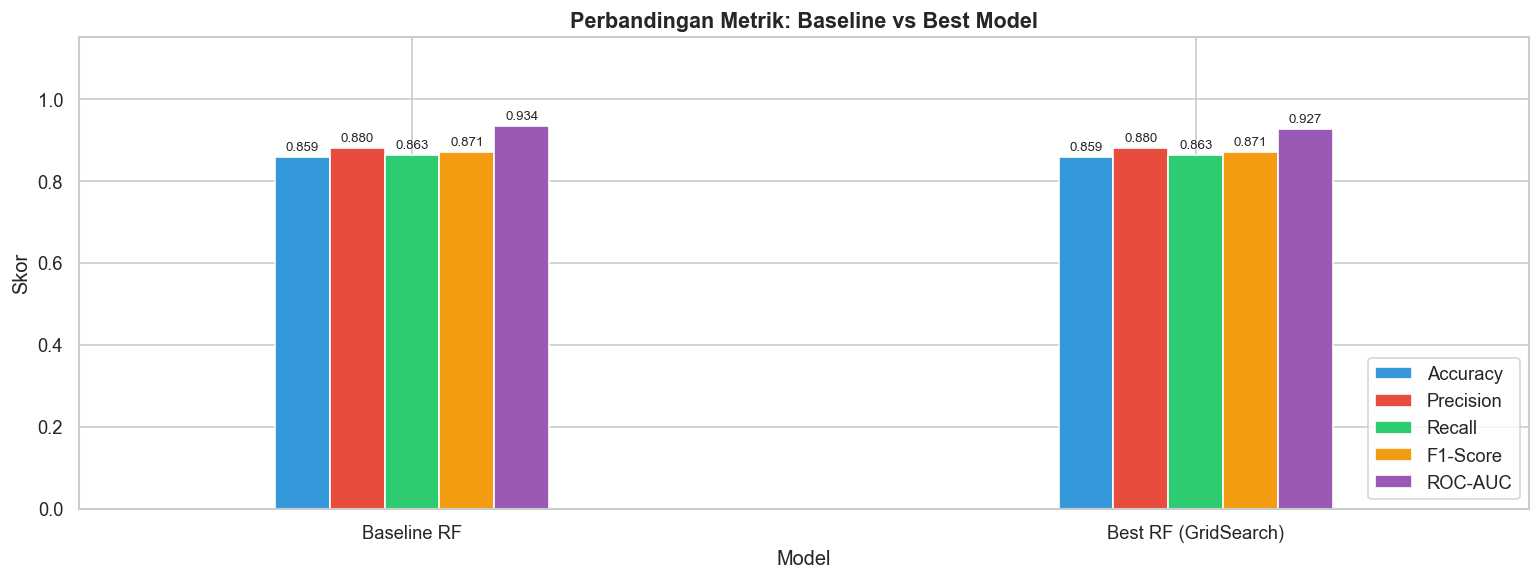

In [29]:
y_prob_base  = baseline_rf.predict_proba(X_test_proc)[:, 1]
roc_base     = roc_auc_score(y_test, y_prob_base)

comparison = pd.DataFrame({
    'Model'    : ['Baseline RF', 'Best RF (GridSearch)'],
    'Accuracy' : [accuracy_score(y_test, y_pred_base), acc_best],
    'Precision': [precision_score(y_test, y_pred_base), prec_best],
    'Recall'   : [recall_score(y_test, y_pred_base), rec_best],
    'F1-Score' : [f1_score(y_test, y_pred_base), f1_best],
    'ROC-AUC'  : [roc_base, roc_best]
})
comparison = comparison.set_index('Model')

print('=== Perbandingan Performa Model ===')
display(comparison.round(4))

# Bar chart perbandingan
ax = comparison.plot(kind='bar', figsize=(13, 5), edgecolor='white',
                     color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'],
                     width=0.35)
ax.set_title('Perbandingan Metrik: Baseline vs Best Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Skor')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

# 7. Kesimpulan

## Ringkasan Eksperimen

Eksperimen machine learning untuk **deteksi penyakit jantung** menggunakan dataset Heart Failure Prediction (Kaggle) telah berhasil diselesaikan dan diperbaiki. Berikut ringkasan tahapan yang dilakukan:

| Tahap | Keterangan |
|-------|------------|
| **Dataset** | Heart Failure Prediction – 918 instance, 11 fitur klinis (sumber: Kaggle) |
| **Target** | Klasifikasi biner: Sehat (0) vs Penyakit Jantung (1) |
| **Anomali Data** | Tidak ada *missing values*. Nilai anomali Cholesterol = 0 (172 baris, 18.74%) dan RestingBP = 0 (1 baris) diganti dengan **median** dari nilai valid |
| **Outlier** | Capping menggunakan metode IQR (faktor 1.5) pada kolom `RestingBP`, `Cholesterol`, dan `Oldpeak` — data tidak dihapus |
| **Encoding** | **Label Encoding** untuk fitur biner: `Sex` (F=0, M=1) dan `ExerciseAngina` (N=0, Y=1); **One-Hot Encoding** (`get_dummies`, drop_first=True) untuk `ChestPainType`, `RestingECG`, dan `ST_Slope` |
| **Preprocessing** | `StandardScaler` di-*fit* **hanya pada `X_train`** setelah split, lalu `.transform()` diterapkan pada `X_test` — menghindari *data leakage* |
| **Class Imbalance** | Diperiksa otomatis: rasio imbalance dataset ini ≈ 0.807 (410 negatif / 508 positif), **di atas threshold 0.8** sehingga SMOTE **tidak diterapkan** |
| **Algoritma** | Random Forest Classifier |
| **Tuning** | GridSearchCV + StratifiedKFold (k=5), optimasi F1-Score; ruang pencarian 162 kombinasi × 5 fold = 810 model fits |
| **Tracking** | Semua eksperimen dilog menggunakan MLflow dengan URI yang valid (`Path.as_uri()`) |

## Insight Utama

- **Fitur terpenting** yang mempengaruhi prediksi adalah `ST_Slope`, `Oldpeak`, `ChestPainType`, `MaxHR`, dan `ExerciseAngina`.
- Model Best RF (hasil GridSearchCV) meningkatkan performa dibanding Baseline RF melalui optimasi hyperparameter yang sistematis.
- **Recall** adalah metrik yang paling kritis dalam konteks medis — *false negative* (pasien sakit diklasifikasikan sehat) jauh lebih berbahaya daripada *false positive*.
- Dataset ini **relatif seimbang** (508 positif vs 410 negatif, rasio 0.807), sehingga SMOTE secara otomatis tidak diterapkan pada eksperimen ini.
- Perbaikan *data leakage* pada scaling menjamin evaluasi model lebih **realistis dan valid** karena test set benar-benar tidak pernah dilihat saat training.
